# NVIDIA Analysis 

### Motivation
Since NVDIA was a very popular stock in the past two years with high volatility as well as, we hypothesize, non-log-normal returns, we aim to check if a KDE model would be able to better model the behavior of the stock in a Monte Carlo simulation. 

### Goals 
1. Perform a goodness-of-fit test to check our assertion that the NVDIA returns are not log-normal
2. Perform a Kernel Density Estimation of the geomtric returns distribution 
3. Perform two Monte-Carlo Simulations - one sampling from log-normal distribution fitted on the geometric returns and one sampling from the KDE-fitted distribution, and compare the results. Will be fitted on the data from the first 3/4 of the data (1.5 years) and tested on the last quarter of the data (0.5 years)

## Part 1: Testing the Log-Normality Assumption

In [49]:
import pandas as pd
import numpy as np

# Load the Excel file
df = pd.read_excel('nvidia_data.xlsx')

# Extract the 'Adj Close' column and convert to NumPy array and clean it up
adj_close_prices = pd.to_numeric(df['Adj Close'], errors='coerce').dropna().to_numpy()
log_returns = np.log(adj_close_prices[1:] / adj_close_prices[:-1])

# log_returns

Mean Return: 1.0025885355387516;   St. Dev. of Returns: 1.0330203755231326


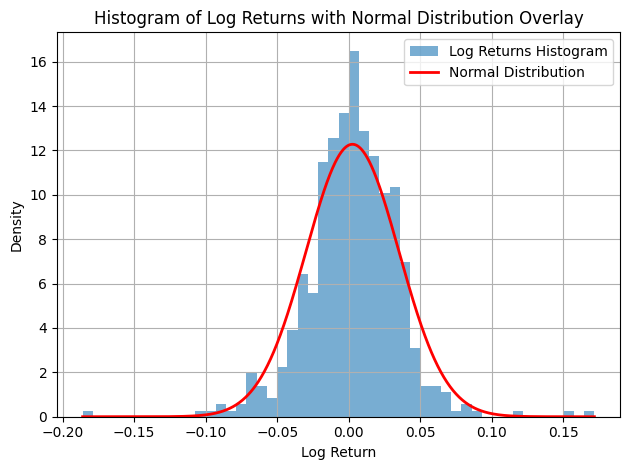

In [40]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Compute mean and standard deviation of log returns
mu, sigma = np.mean(log_returns), np.std(log_returns)
print(f"Mean Return: {np.e**mu};   St. Dev. of Returns: {np.e**sigma}")

# Plot histogram of log returns
count, bins, ignored = plt.hist(log_returns, bins=50, density=True, alpha=0.6, label='Log Returns Histogram')

# Plot normal distribution curve
x = np.linspace(min(log_returns), max(log_returns), 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')

# Add labels and legend
plt.title('Histogram of Log Returns with Normal Distribution Overlay')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Even though the distirbution is central, it's not quite symmetric. It is worth performing two goodness-of-fit tests to check: one is a Lilliefors test (variant of Kolmogorov-Smirnov for parameters estimated from the sample) and the other is a Chi-Squared GoF test, which is also appropriate given the large sample size of around $n=500$. 

We denote by $\mathbf{x}$ the `log_returns` array, and we formulate our hypothesis test as follows: 
$H_0$: $\mathbf{x}\sim \mathcal{N} (\bar{x}, s^2)$ vs. $H_A$: otherwise. We test at a significance level $\alpha=0.05$.

In [41]:
import scipy.stats as stats

# Compute parameters
mu, sigma = np.mean(log_returns), np.std(log_returns)
n = len(log_returns)
num_bins = 10

# Create quantile-based bins
quantiles = np.linspace(0, 1, num_bins + 1)
bin_edges = stats.norm.ppf(quantiles, loc=mu, scale=sigma)

# Clip extreme values just in case
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

# Count observed frequencies
observed_freq, _ = np.histogram(log_returns, bins=bin_edges)

# Expected frequencies: each bin should ideally have same count
expected_freq = np.array([n / num_bins] * num_bins)

# Adjust expected frequencies to match observed total exactly
expected_freq *= observed_freq.sum() / expected_freq.sum()

# Chi-squared test
chi2_stat, p_value = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)

print("Chi-squared Statistic:", chi2_stat)
print("p-value:", p_value)


Chi-squared Statistic: 25.4
p-value: 0.002559145881638447


In [42]:
from statsmodels.stats.diagnostic import lilliefors

# Perform Lilliefors test (normality)
statistic, p_value = lilliefors(log_returns)

print("Lilliefors test statistic:", statistic)
print("p-value:", p_value)


Lilliefors test statistic: 0.05533302529047257
p-value: 0.0018668819936490044


Both tests result in p-values $<\alpha=0.05$, therefore, we can reject the null hypothesis that the returns come from a normal distribution. 

## Part 2: Fitting a KDE 

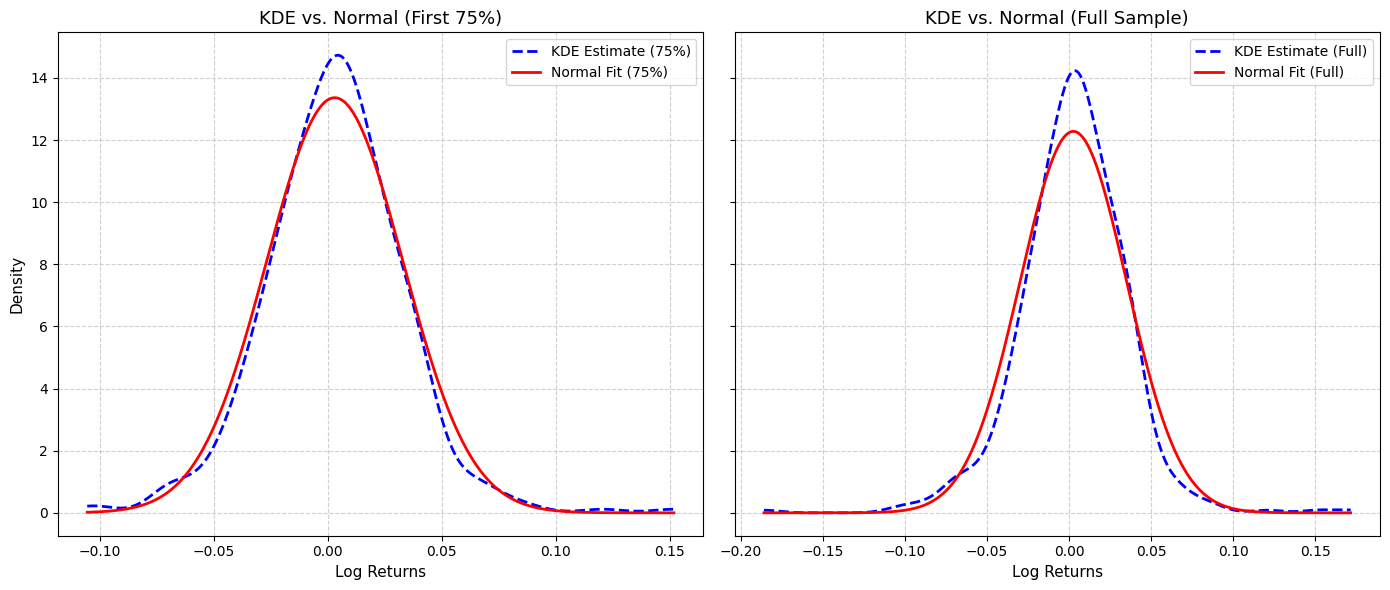

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# Function for KDE
def kernel_density_estimate(sample):
    kde = gaussian_kde(sample)
    x_vals = np.linspace(min(sample), max(sample), 1000)
    y_vals = kde(x_vals)
    return x_vals, y_vals

# Split the data
n = len(log_returns)
log_returns_75 = log_returns[:int(0.75 * n)]

# KDE and normal params for full sample
mu_full, sigma_full = np.mean(log_returns), np.std(log_returns)
x_full = np.linspace(min(log_returns), max(log_returns), 1000)
x_kde_full, y_kde_full = kernel_density_estimate(log_returns)

# KDE and normal params for first 75%
mu_75, sigma_75 = np.mean(log_returns_75), np.std(log_returns_75)
x_75 = np.linspace(min(log_returns_75), max(log_returns_75), 1000)
x_kde_75, y_kde_75 = kernel_density_estimate(log_returns_75)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for first 3/4
axes[0].plot(x_kde_75, y_kde_75, "b--", linewidth=2, label="KDE Estimate (75%)")
axes[0].plot(x_75, norm.pdf(x_75, mu_75, sigma_75), 'r-', linewidth=2, label='Normal Fit (75%)')
axes[0].set_title("KDE vs. Normal (First 75%)", fontsize=13)
axes[0].set_xlabel("Log Returns", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot for full sample
axes[1].plot(x_kde_full, y_kde_full, "b--", linewidth=2, label="KDE Estimate (Full)")
axes[1].plot(x_full, norm.pdf(x_full, mu_full, sigma_full), 'r-', linewidth=2, label='Normal Fit (Full)')
axes[1].set_title("KDE vs. Normal (Full Sample)", fontsize=13)
axes[1].set_xlabel("Log Returns", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Part 3: Two Monte Carlo Simulations

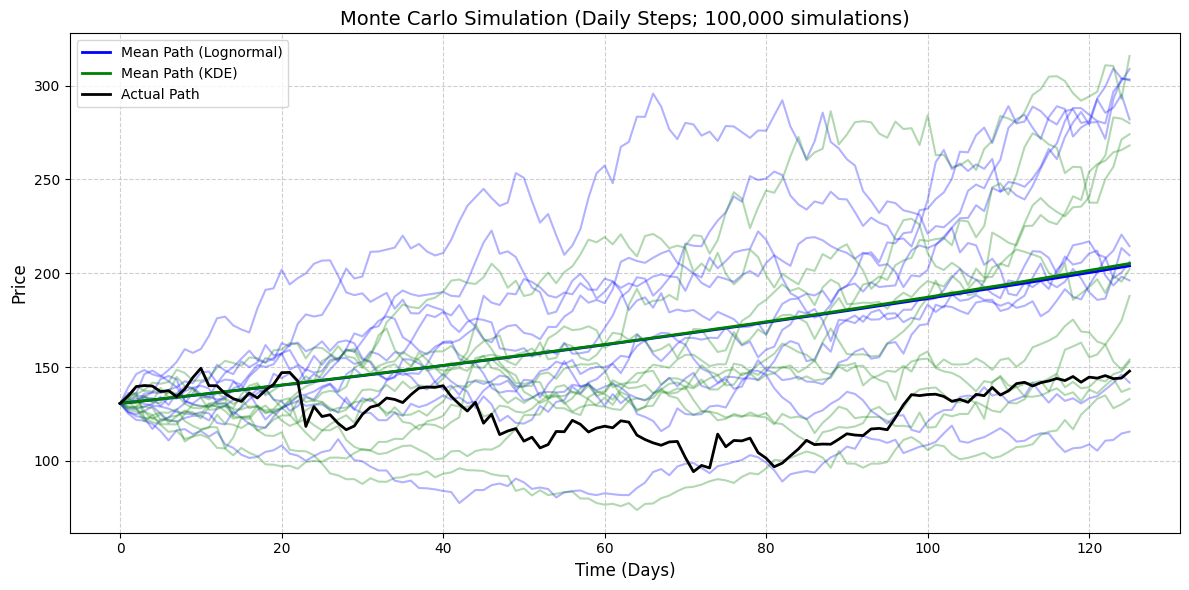

In [44]:
# Parameters
start_index = int(0.75 * len(log_returns))
n_steps = len(log_returns) - start_index
n_paths = 100_000
start_price = adj_close_prices[start_index]

# Time grid (in days)
time_grid = np.arange(n_steps + 1)

# Simulate lognormal
lognormal_paths = np.zeros((n_paths, n_steps + 1))
lognormal_paths[:, 0] = start_price

for i in range(n_paths):
    sampled_returns = np.random.normal(mu_75, sigma_75, n_steps)
    log_prices = np.log(start_price) + np.cumsum(sampled_returns)
    lognormal_paths[i, 1:] = np.exp(log_prices)

# Simulate KDE
kde_paths = np.zeros((n_paths, n_steps + 1))
kde_paths[:, 0] = start_price

kde_probs = y_kde_75 / np.sum(y_kde_75)

for i in range(n_paths):
    sampled_returns = np.random.choice(x_kde_75, size=n_steps, p=kde_probs)
    log_prices = np.log(start_price) + np.cumsum(sampled_returns)
    kde_paths[i, 1:] = np.exp(log_prices)

# Plot
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(time_grid, lognormal_paths[i], color='blue', alpha=0.3)
for i in range(10):
    plt.plot(time_grid, kde_paths[i], color='green', alpha=0.3)

plt.plot(time_grid, np.mean(lognormal_paths, axis=0), color='blue', label='Mean Path (Lognormal)', linewidth=2)
plt.plot(time_grid, np.mean(kde_paths, axis=0), color='green', label='Mean Path (KDE)', linewidth=2)

# Actual path (daily)
actual_path = adj_close_prices[start_index:start_index + n_steps + 1]
actual_time = np.arange(len(actual_path))
plt.plot(actual_time, actual_path, color='black', linewidth=2, label='Actual Path')

plt.title(f"Monte Carlo Simulation (Daily Steps; {100_000:,} simulations)", fontsize=14)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Part 4: Conclusions

I tested the results with several other stocks, including ones with higher kurtosis, to assess how well a lognormal distribution versus a non-parametric KDE model captures the evolution of stock prices in a Monte Carlo setting.

Despite the fact that goodness-of-fit tests often reject the lognormal assumption (e.g., due to excess kurtosis or skewness in log returns), the lognormal model consistently produced simulated paths with lower RMSE when compared to the actual price trajectories. 

This suggests that while KDE may provide a better static fit to the empirical return distribution, it may not be as reliable dynamically when used in iterative simulation over time. This is likely because KDE does not encode any structural constraints or assumptions about temporal coherence, leading to noisier or pathologically drifting simulations, especially over long horizons.

In contrast, the lognormal model, by enforcing a stable drift-diffusion structure, offers greater path consistency, even if it slightly underrepresents tail behavior.

In [45]:
from sklearn.metrics import root_mean_squared_error

# Recompute mean paths (just to be safe)
mean_lognormal = np.mean(lognormal_paths, axis=0)
mean_kde = np.mean(kde_paths, axis=0)

# Trim actual path to match time length (should be same length as mean paths)
actual_trimmed = actual_path[:len(mean_lognormal)]

# Compute RMSE
rmse_lognormal = root_mean_squared_error(actual_trimmed, mean_lognormal)
rmse_kde = root_mean_squared_error(actual_trimmed, mean_kde)

print(f"RMSE (Lognormal): {rmse_lognormal:.4f}")
print(f"RMSE (KDE):       {rmse_kde:.4f}")


RMSE (Lognormal): 46.4909
RMSE (KDE):       46.9232


## Part 5: Additional VaR analysis

In [46]:
confidence_level = 0.95
alpha = 1 - confidence_level

# Extract final prices
final_prices_lognormal = lognormal_paths[:, -1]
final_prices_kde = kde_paths[:, -1]

# Price-based VaR
VaR_lognormal = start_price - np.quantile(final_prices_lognormal, alpha)
VaR_kde = start_price - np.quantile(final_prices_kde, alpha)

# Return-based VaR (log returns)
returns_lognormal = np.log(final_prices_lognormal / start_price)
returns_kde = np.log(final_prices_kde / start_price)

VaR_return_lognormal = np.quantile(returns_lognormal, alpha)
VaR_return_kde = np.quantile(returns_kde, alpha)

print(f"Price-based VaR (Lognormal, 95%): {VaR_lognormal:.2f}")
print(f"Price-based VaR (KDE, 95%):       {VaR_kde:.2f}")
print()
print(f"Return-based VaR (Lognormal, 95%): {VaR_return_lognormal:.4f}")
print(f"Return-based VaR (KDE, 95%):       {VaR_return_kde:.4f}")


Price-based VaR (Lognormal, 95%): 19.63
Price-based VaR (KDE, 95%):       19.42

Return-based VaR (Lognormal, 95%): -0.1628
Return-based VaR (KDE, 95%):       -0.1609


In [47]:
# Actual final return
actual_final_price = actual_path[-1]
actual_return = np.log(actual_final_price / start_price)

# Compare to VaR
print(f"Actual log return: {actual_return:.4f}")
print()

if actual_return < VaR_return_lognormal:
    print("⚠️  Actual return breached lognormal VaR (95%)")
else:
    print("✅  Actual return is above lognormal VaR (95%)")

if actual_return < VaR_return_kde:
    print("⚠️  Actual return breached KDE VaR (95%)")
else:
    print("✅  Actual return is above KDE VaR (95%)")


Actual log return: 0.1239

✅  Actual return is above lognormal VaR (95%)
✅  Actual return is above KDE VaR (95%)


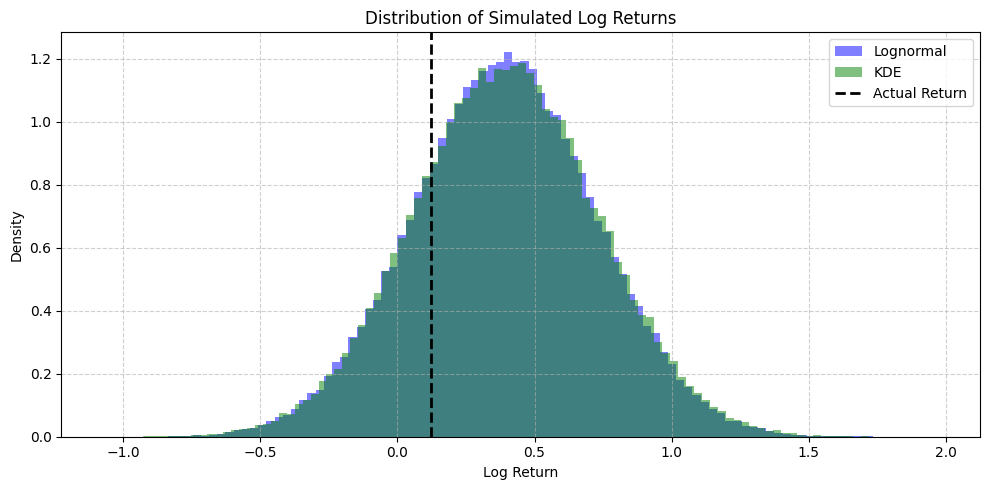

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(returns_lognormal, bins=100, alpha=0.5, label='Lognormal', color='blue', density=True)
plt.hist(returns_kde, bins=100, alpha=0.5, label='KDE', color='green', density=True)
plt.axvline(actual_return, color='black', linestyle='--', linewidth=2, label='Actual Return')

plt.title("Distribution of Simulated Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Both the lognormal and KDE models estimated similar 95% Value at Risk (VaR), with return-based thresholds around −16%. However, the actual return was +12.39%, well above both risk thresholds. This indicates that neither model underestimated tail risk in this case — in fact, both were relatively conservative. Despite KDE offering a more flexible fit to historical returns, the lognormal model performed comparably in terms of downside risk estimation.